ADF p-value: 0.0000


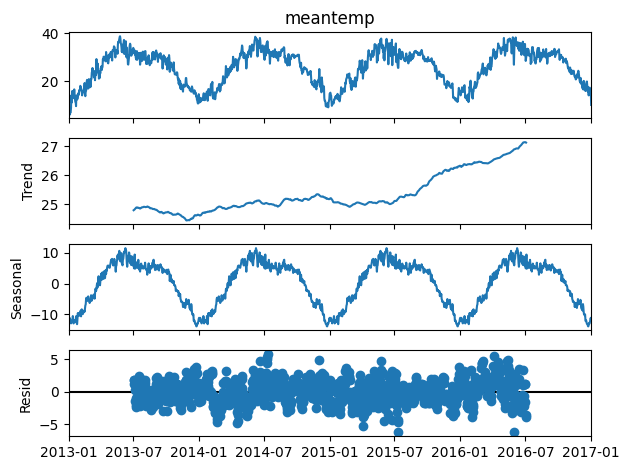

In [12]:
%pip install pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error

df = pd.read_csv('DailyDelhiClimateTrain.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
ts = df['meantemp']

result = adfuller(ts.diff().dropna())
print(f'ADF p-value: {result[1]:.4f}')

decomp = seasonal_decompose(ts, model='additive', period=365)
decomp.plot()
plt.tight_layout()
plt.show()

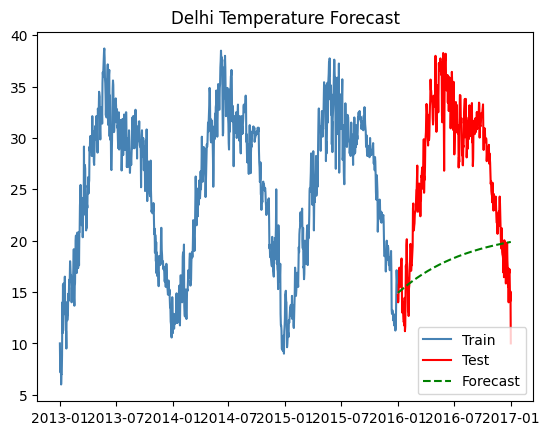

RMSE: 11.23


In [14]:
train = ts[:'2015-12-31']
test = ts['2016-01-01':]

model = auto_arima(train, seasonal=True, m=7,
                   start_p=1, start_q=1, max_p=2, max_q=2,
                   trace=False, suppress_warnings=True)
model.fit(train)
forecast = model.predict(n_periods=len(test))

plt.plot(train, label='Train', color='steelblue')
plt.plot(test, label='Test', color='red')
plt.plot(forecast, label='Forecast', color='green', linestyle='--')
plt.legend()
plt.title('Delhi Temperature Forecast')
plt.show()

print(f'RMSE: {np.sqrt(mean_squared_error(test, forecast)):.2f}')